# 🩺 Breast Cancer Classification using Machine Learning

## 📌 Project Overview
Breast cancer is one of the most common cancers affecting women worldwide.  
Early and accurate detection plays a critical role in improving survival rates and guiding effective treatment decisions.

This project focuses on building and evaluating **machine learning classification models** to predict whether a breast tumor is **Benign (B)** or **Malignant (M)** based on diagnostic features extracted from medical data.

---

## 🎯 Objectives
- To perform **exploratory data analysis (EDA)** on breast cancer diagnostic data  
- To preprocess and prepare data for machine learning models  
- To train and compare multiple **classification algorithms**  
- To evaluate models using **F1-score, cross-validation, and stability metrics**  
- To identify the **best-performing and most reliable model**

---

## 🧠 Problem Statement
Given a set of numerical features computed from breast mass images, the goal is to classify each tumor as:
- **B (Benign)** – Non-cancerous  
- **M (Malignant)** – Cancerous  

This is a **binary classification problem** with a strong emphasis on minimizing **false negatives**, as misclassifying a malignant tumor can have serious consequences.

---

## 📊 Dataset Description
The dataset contains diagnostic measurements such as:
- Radius, texture, perimeter, area, smoothness
- Compactness, concavity, symmetry
- Fractal dimension and related statistical features

Each record represents a single tumor sample with a corresponding diagnosis label.

---

## 🧪 Models Evaluated
The following machine learning models are trained and evaluated:
- Logistic Regression
- Random Forest Classifier
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Decision Tree Classifier

Model performance is assessed using **k-fold cross-validation** with the **F1-score** as the primary evaluation metric.

---

## 🏆 Evaluation Strategy
- **F1-score** to balance precision and recall  
- **Cross-validation** to ensure generalization  
- **Standard deviation** of scores to measure model stability  
- Final evaluation on a **hold-out test set**

---

## 📌 Expected Outcome
The project aims to select a model that:
- Achieves **high predictive performance**
- Demonstrates **low variance across folds**
- Is suitable for **real-world medical decision support**

---

> ⚠️ *Disclaimer:* This project is for educational and research purposes only and should not be used as a substitute for professional medical diagnosis.


## Data Acquisition and Required Libraries


In [1]:
import pandas as pd, numpy as np
import kagglehub

import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 

In [2]:
df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
  "yasserh/breast-cancer-dataset",
    'breast-cancer.csv')

## Data OverView

In [3]:
df.sample(7)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
317,894326,M,18.220,18.87,118.70,1027.0,0.09746,0.11170,0.11300,0.07950,...,21.84,25.00,140.90,1485.0,0.1434,0.2763,0.3853,0.1776,0.2812,0.08198
213,881094802,M,17.420,25.56,114.50,948.0,0.10060,0.11460,0.16820,0.06597,...,18.07,28.07,120.40,1021.0,0.1243,0.1793,0.2803,0.1099,0.1603,0.06818
15,84799002,M,14.540,27.54,96.73,658.8,0.11390,0.15950,0.16390,0.07364,...,17.46,37.13,124.10,943.2,0.1678,0.6577,0.7026,0.1712,0.4218,0.13410
117,864729,M,14.870,16.67,98.64,682.5,0.11620,0.16490,0.16900,0.08923,...,18.81,27.37,127.10,1095.0,0.1878,0.4480,0.4704,0.2027,0.3585,0.10650
176,872608,B,9.904,18.06,64.60,302.4,0.09699,0.12940,0.13070,0.03716,...,11.26,24.39,73.07,390.2,0.1301,0.2950,0.3486,0.0991,0.2614,0.11620
370,9012315,M,16.350,23.29,109.00,840.4,0.09742,0.14970,0.18110,0.08773,...,19.38,31.03,129.30,1165.0,0.1415,0.4665,0.7087,0.2248,0.4824,0.09614
88,861597,B,12.360,21.80,79.78,466.1,0.08772,0.09445,0.06015,0.03745,...,13.83,30.50,91.46,574.7,0.1304,0.2463,0.2434,0.1205,0.2972,0.09261


In [4]:
df = df.drop('id',axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['diagnosis'] = df['diagnosis'].map({"B":0,"M":1})

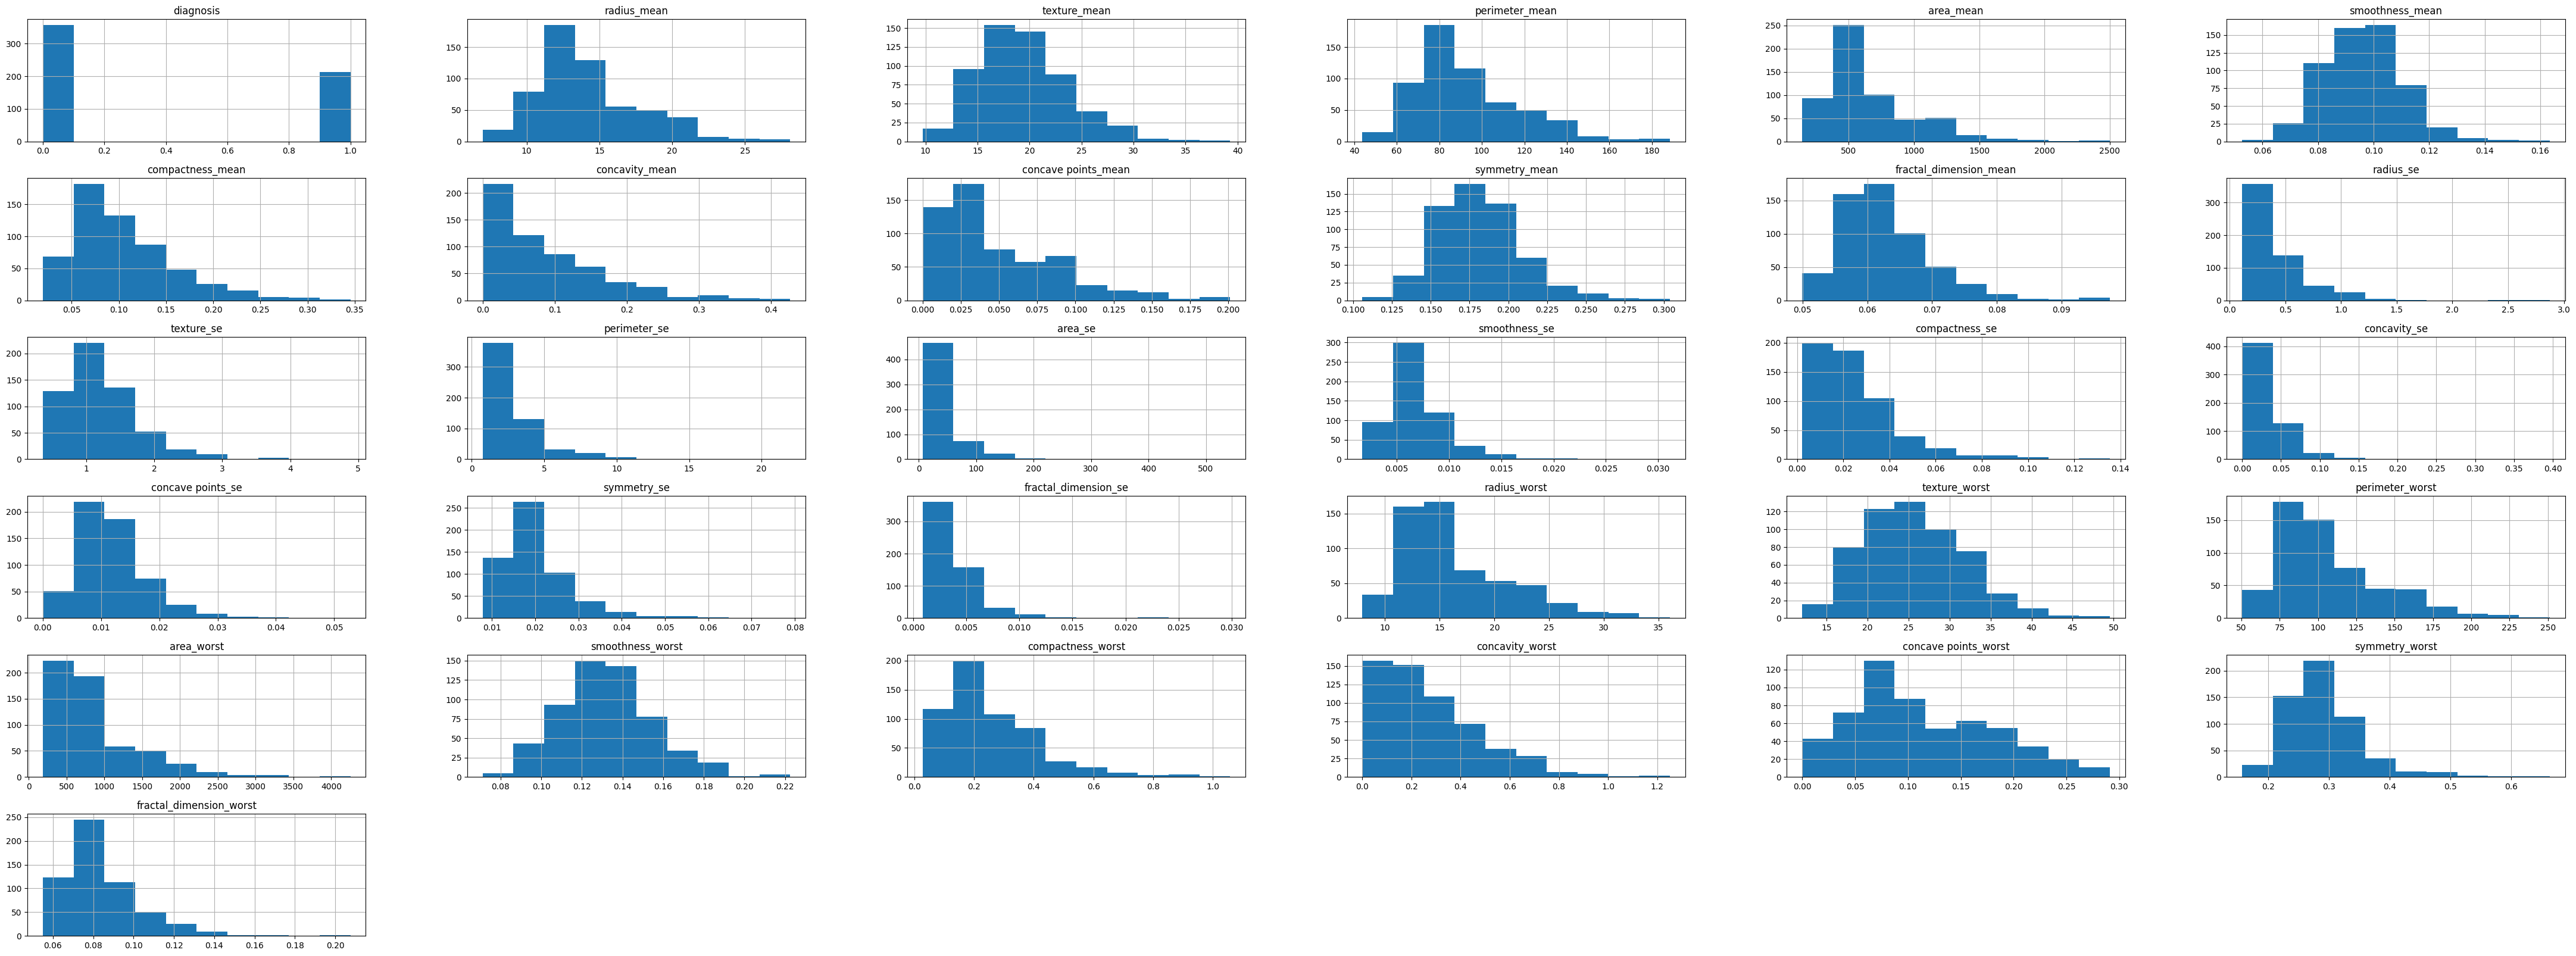

In [8]:
df.hist(figsize=(55,20))
plt.show()

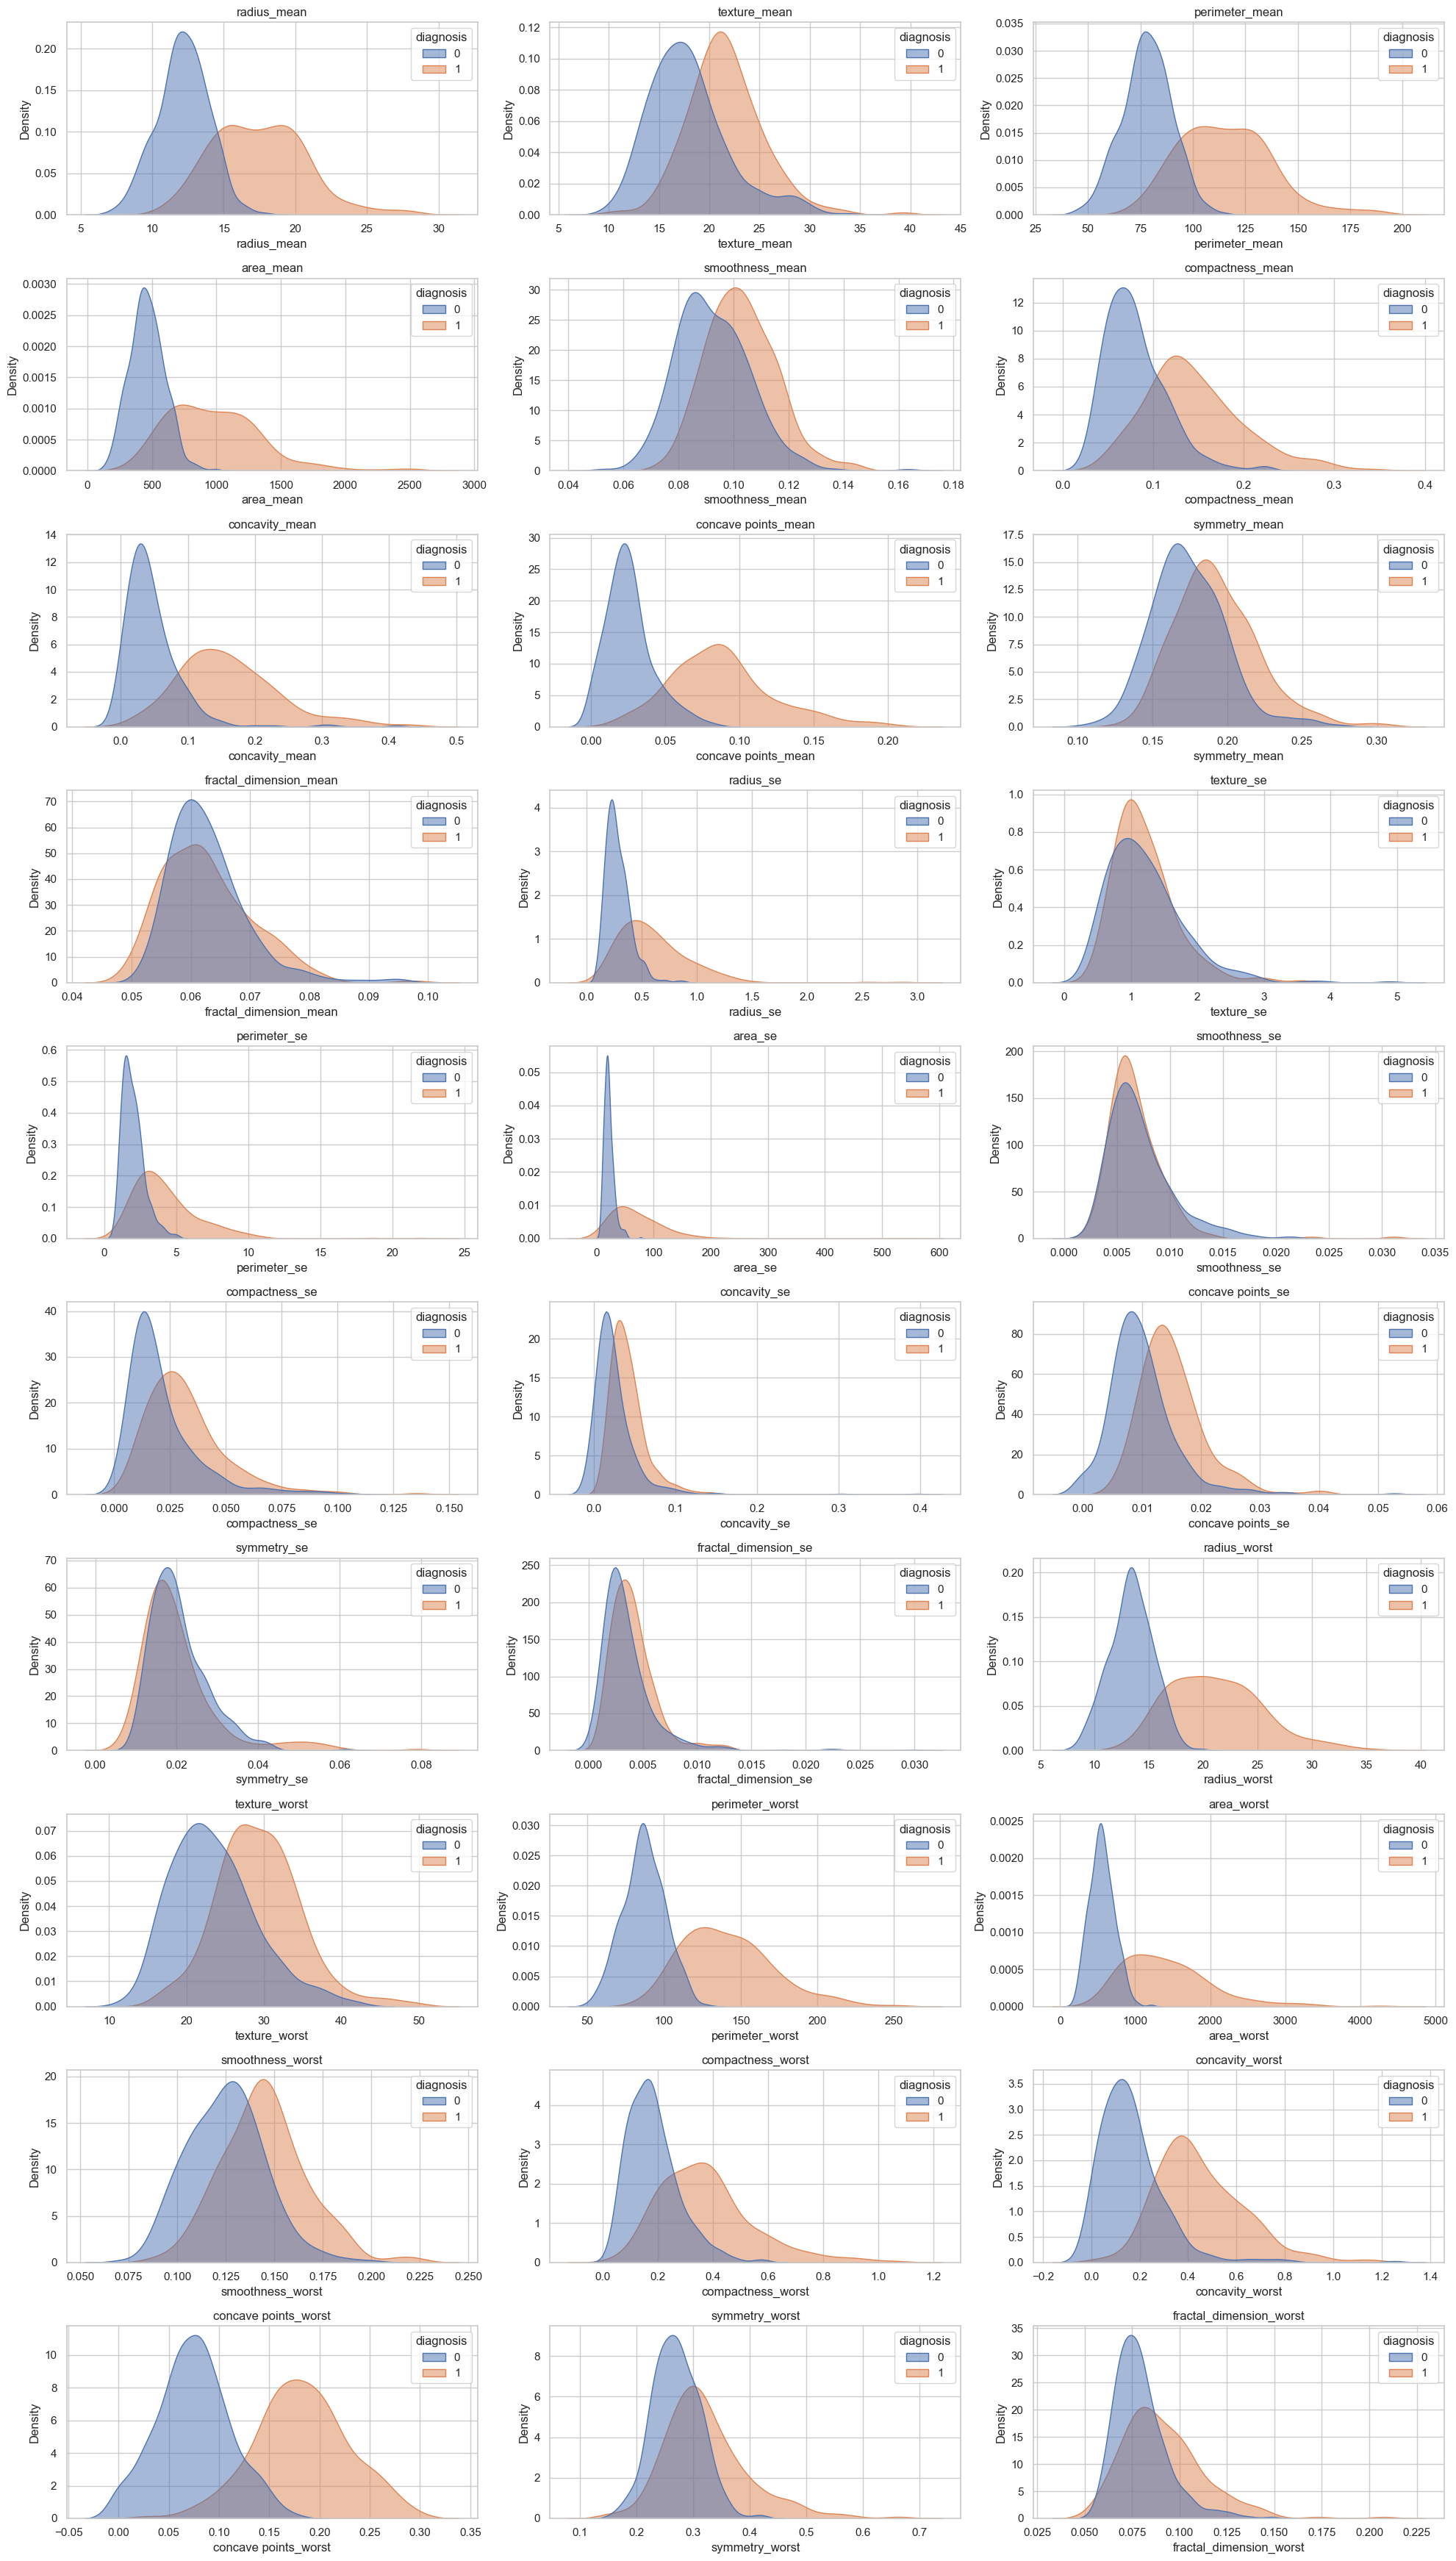

In [9]:
sns.set(style="whitegrid")

target = 'diagnosis'
num_cols = df.drop(columns=[target]).select_dtypes(include='number').columns

# Create 10x3 subplot grid
fig, axes = plt.subplots(10, 3, figsize=(20, 35))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue=target,
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots if any
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 📊 KDE Plot Insights (Benign vs Malignant)

### 🔍 Strongly Discriminative Features
The following features show clear separation between benign (0) and malignant (1) tumors and are highly predictive:
- radius_mean, radius_worst  
- perimeter_mean, perimeter_worst  
- area_mean, area_worst  
- concavity_mean, concavity_worst  
- concave_points_mean, concave_points_worst  
- compactness_mean, compactness_worst  

Malignant tumors consistently exhibit higher values for these features, indicating larger and more irregular cell structures.

---

### 🧠 Moderately Informative Features
These features show partial overlap between classes but still contribute useful information:
- texture_mean, texture_worst  
- symmetry_mean, symmetry_worst  
- smoothness_mean, smoothness_worst  

They help refine model decision boundaries but are not strong predictors on their own.

---

### ⚠️ Weakly Informative Features
The following features show significant overlap and limited individual discriminative power:
- fractal_dimension_mean  
- fractal_dimension_se and fractal_dimension_worst  
- Several standard error (SE) features  

These features are more effective when combined with stronger predictors.

---

### 📈 Importance of “Worst” Features
Across most attributes, the **worst-case measurements** provide better class separation than mean or standard error values.  
This suggests that extreme tumor characteristics are more indicative of malignancy than average measurements.

---

### 📐 Distribution Characteristics
- Malignant feature distributions are generally right-skewed, reflecting aggressive tumor growth.
- Benign distributions are more compact and left-shifted.

This distribution behavior supports the strong performance of linear classification models.

---

### 🏆 Key Takeaway
Size-related and shape-irregularity features are the most critical indicators of malignancy, while texture and fractal features provide secondary support in classification.


In [10]:
df.describe().style.background_gradient('Blues')

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Data Spliting

In [11]:
X = df.drop('diagnosis',axis=1)
y = df.diagnosis

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
y_train.value_counts()

diagnosis
0    285
1    170
Name: count, dtype: int64

In [14]:
y_test.value_counts()

diagnosis
0    72
1    42
Name: count, dtype: int64

## Model Building, Training, and Performance Evaluation


## Baseline Classification Models


In [15]:
models = {
    'lgr':Pipeline([('scaler',StandardScaler()),
                    ('lgr',LogisticRegression())]),
    'dt':DecisionTreeClassifier(random_state=42),
    'rf':RandomForestClassifier(random_state=42),
    'knn':KNeighborsClassifier(weights='distance'),
    'svm':SVC()
}

In [16]:
models['lgr'].fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lgr', LogisticRegression())])

In [17]:
for name,model in models.items():
    model.fit(X_train,y_train)
    print(f"{name} score : ",model.score(X_test,y_test))

lgr score :  0.9649122807017544
dt score :  0.9298245614035088
rf score :  0.9736842105263158
knn score :  0.9122807017543859
svm score :  0.9035087719298246


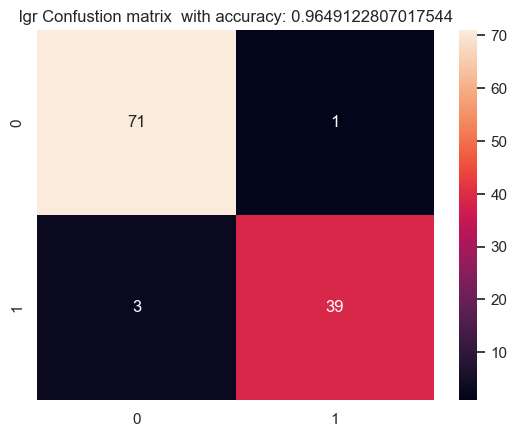

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-


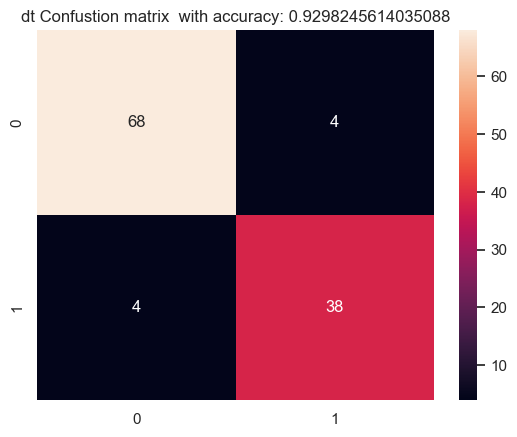

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-


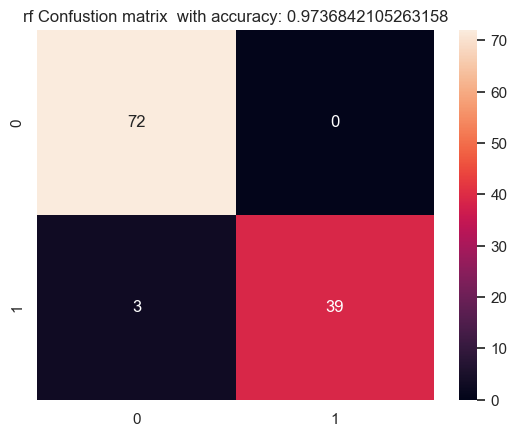

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-


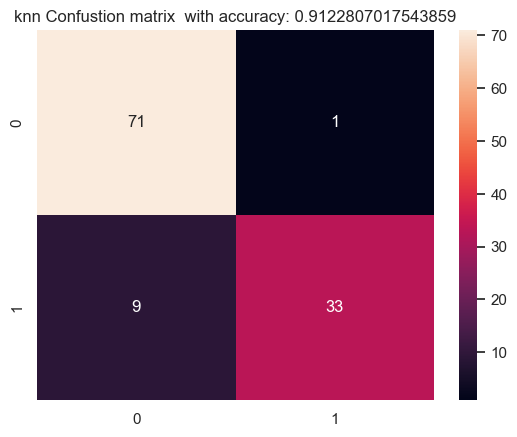

              precision    recall  f1-score   support

           0       0.89      0.99      0.93        72
           1       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-


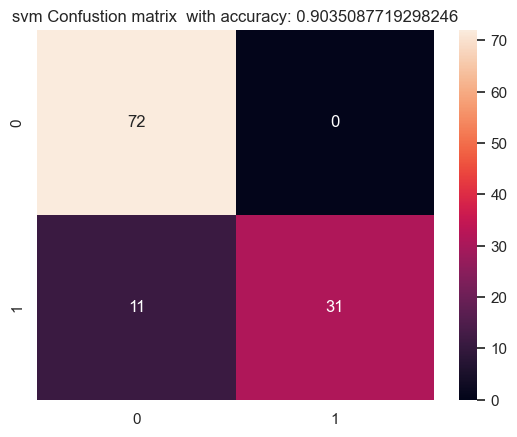

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        72
           1       1.00      0.74      0.85        42

    accuracy                           0.90       114
   macro avg       0.93      0.87      0.89       114
weighted avg       0.92      0.90      0.90       114

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-


In [18]:
for n,m in models.items():
    y_pred = m.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)
    sns.heatmap(cm,annot=True,fmt='d').set_title(f"{n} Confustion matrix  with accuracy: {accuracy_score(y_test,y_pred)}")
    plt.show()
    print(classification_report(y_test,y_pred))
    print("+-"*89)

## 📌 Model Evaluation Summary

- **Logistic Regression (LGR):**  
  Demonstrates strong and consistent performance with high accuracy and balanced precision–recall. It correctly classifies most malignant cases, making it a reliable and interpretable choice.

- **Random Forest (RF):**  
  Achieves the highest accuracy among all models but shows slightly higher variance. While performance is strong, interpretability is lower compared to Logistic Regression.

- **Decision Tree (DT):**  
  Provides moderate performance and is prone to overfitting, resulting in reduced generalization on unseen data.

- **K-Nearest Neighbors (KNN):**  
  Shows acceptable accuracy but misclassifies a higher number of malignant cases, which is undesirable in medical diagnosis.

- **Support Vector Machine (SVM):**  
  Records the lowest performance with reduced recall for malignant tumors, limiting its effectiveness for this task.
----
### 🏆 Final Conclusion
Based on accuracy, recall for malignant cases, stability, and interpretability, **Logistic Regression** is selected as the final model for breast cancer classification.


In [19]:
models = {
    'lgr':Pipeline([('scaler',StandardScaler()),
                    ('lgr',LogisticRegression())]),
    'dt':DecisionTreeClassifier(random_state=42),
    'rf':RandomForestClassifier(random_state=42),
    'knn':KNeighborsClassifier(weights='distance'),
    'svm':SVC()
}

In [20]:
for n,m in models.items():
    cvs = cross_val_score(m,X,y,scoring='f1',n_jobs=-1,cv=10)
    print(f"{n} mean : ",cvs.mean(), '\t std: ',cvs.std())

lgr mean :  0.9734924686456166 	 std:  0.02046364755409401
dt mean :  0.9037729964676375 	 std:  0.04515201082977469
rf mean :  0.9496055227308773 	 std:  0.042857019738695316
knn mean :  0.9026804855193966 	 std:  0.037368828083347454
svm mean :  0.8734791742044632 	 std:  0.04622688615641731


## 📈 Cross-Validation Results Summary

Multiple classification models were evaluated using **10-fold cross-validation** with the **F1-score** as the primary metric to ensure a balanced assessment of precision and recall.

### 🔍 Performance Comparison
- **Logistic Regression (with Standard Scaling)** achieved the **highest mean F1-score** and the **lowest standard deviation**, indicating excellent performance and strong stability across folds.
- **Random Forest** also performed well with a high mean F1-score but exhibited greater variability, suggesting sensitivity to data splits.
- **K-Nearest Neighbors** showed moderate performance with acceptable stability but was less competitive than linear and ensemble models.
- **Decision Tree** demonstrated lower performance and higher variance, indicating a tendency to overfit.
- **Support Vector Machine** recorded the lowest F1-score and the highest variability, making it the least reliable model in this comparison.

### 🏆 Final Insight
Overall, **Logistic Regression** emerged as the most reliable model due to its superior F1-score, low variance, and consistent performance, making it well-suited for this breast cancer classification task.


---
# 🔧 Hyperparameter Tuning using GridSearchCV (Random Forest)

In this section, **hyperparameter tuning** is performed on the **Random Forest classifier** to improve its performance and reduce overfitting.

### ⚙️ Methodology
- **Algorithm:** Random Forest Classifier  
- **Tuning Technique:** GridSearchCV  
- **Evaluation Metric:** F1-score  
- **Cross-Validation:** 5-fold  
- **Class Imbalance Handling:** `class_weight='balanced'`  

GridSearchCV systematically evaluates different combinations of hyperparameters to identify the configuration that yields the best F1-score.

---

In [21]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

In [22]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

gs = GridSearchCV(
    rf,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs.fit(X, y)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 400]},
             scoring='f1')

In [23]:
gs.best_params_

{'max_depth': 5,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [24]:
y_pred_best_rf = gs.predict(X_test)

In [25]:
accuracy_score(y_test,y_pred_best_rf)

1.0

In [26]:
print(classification_report(y_test,y_pred_best_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        42

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



<Axes: >

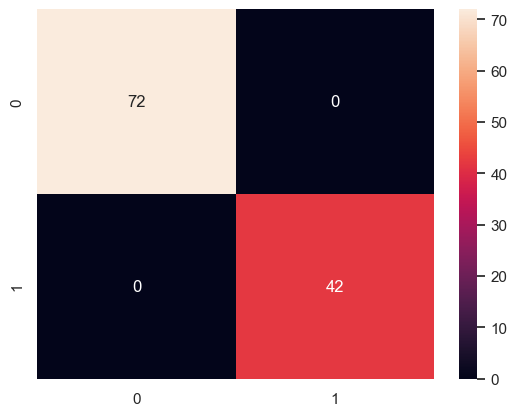

In [27]:
sns.heatmap(confusion_matrix(y_test,y_pred_best_rf),annot=True,fmt='d')

---

### ⭐ Best Hyperparameters Identified
The optimal model configuration obtained from GridSearchCV is:

- `n_estimators = 200`
- `max_depth = 5`
- `max_features = 'log2'`
- `min_samples_split = 2`
- `min_samples_leaf = 1`

---

### 📊 Performance on Test Set
The tuned Random Forest model was evaluated on the held-out test dataset and achieved:

- **Accuracy:** 100%  
- **Precision:** 1.00  
- **Recall:** 1.00  
- **F1-score:** 1.00  

The classification report indicates perfect classification of both benign and malignant cases.

---

### ⚠️ Important Note
Although the tuned model achieves perfect accuracy on the test set, such results may indicate **potential overfitting** or a **favorable test split**.  
Therefore, cross-validation performance should be considered alongside test results when selecting the final model.

---

### 🏁 Insight
While hyperparameter tuning significantly improved Random Forest performance, simpler models such as Logistic Regression demonstrated more stable generalization during cross-validation.
✅

In [36]:
cvs = cross_val_score(gs.best_estimator_,X=X,y=y,scoring='f1',n_jobs=-1,cv=10)

In [37]:
print(f"Best Rf's:\n\tMean: {cvs.mean()} | std: {cvs.std()}")

Best Rf's:
	Mean: 0.9483329030912202 | std: 0.04398443668655534


## 🔍 Cross-Validation of Tuned Random Forest

The best Random Forest model obtained from GridSearchCV was further evaluated using **10-fold cross-validation** with the **F1-score** to assess its generalization performance.

- **Mean F1-score:** 0.95  
- **Standard Deviation:** 0.04  

Although the tuned Random Forest achieved perfect accuracy on the test set, its cross-validation results indicate higher variability and slightly lower performance compared to Logistic Regression. This suggests potential overfitting and confirms that Logistic Regression generalizes more consistently for this dataset.


---
# 🔧 Hyperparameter Tuning using GridSearchCV (Logistic Regression)

In this section, **Logistic Regression** is optimized using **GridSearchCV** within a **Pipeline** to prevent data leakage and ensure robust evaluation.

### ⚙️ Methodology
- **Pipeline Components:**  
  - StandardScaler (feature normalization)  
  - Logistic Regression classifier  
- **Class Imbalance Handling:** `class_weight='balanced'`  
- **Evaluation Metric:** F1-score  
- **Cross-Validation:** 10-fold  

The following hyperparameters were tuned:
- **C** (regularization strength)
- **Penalty** type
- **Solver** selection

---

In [47]:
pipe_lgr = Pipeline([
    ('scaler', StandardScaler()),
    ('lgr', LogisticRegression(
        max_iter=1500,
        class_weight='balanced',
        random_state=42
    ))
])

param_grid_lgr = {
    'lgr__penalty': ['l2'],
    'lgr__C': [0.01, 0.1, 1, 10, 100],
    'lgr__solver': ['lbfgs', 'liblinear']
}

In [48]:
gs_lgr = GridSearchCV(
    pipe_lgr,
    param_grid=param_grid_lgr,
    scoring='f1',
    cv=10,
    n_jobs=-1
)

In [49]:
gs_lgr.fit(X_train,y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lgr',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1500,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'lgr__C': [0.01, 0.1, 1, 10, 100],
                         'lgr__penalty': ['l2'],
                         'lgr__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [50]:
print(f"best LogisticRegression:\n\tbest score: {gs_lgr.best_score_}  |  best params : {gs_lgr.best_params_}")

best LogisticRegression:
	best score: 0.9669907053730583  |  best params : {'lgr__C': 0.1, 'lgr__penalty': 'l2', 'lgr__solver': 'lbfgs'}


In [51]:
cvs_lgr = cross_val_score(gs_lgr.best_estimator_,X=X,y=y,scoring='f1',cv=10)
print(f"Best lgr's:\n\tMean: {cvs_lgr.mean()} | std: {cvs_lgr.std()}")

Best lgr's:
	Mean: 0.9737332649073999 | std: 0.022834442592277467



---

### ⭐ Best Hyperparameters
GridSearchCV identified the following optimal configuration:

- `C = 0.1`
- `penalty = 'l2'`
- `solver = 'lbfgs'`

The best cross-validated F1-score during grid search was **0.97**.

---

### 📊 Cross-Validation of Tuned Model
The tuned Logistic Regression model was further evaluated using **10-fold cross-validation** to assess its generalization and stability.

- **Mean F1-score:** 0.97  
- **Standard Deviation:** 0.02  

These results indicate **excellent performance with low variance**, demonstrating strong generalization across different data splits.

---

### 🏆 Final Insight
The tuned Logistic Regression model achieves the **highest and most stable F1-score** among all evaluated models.  
Given its performance, stability, and interpretability, Logistic Regression is selected as the **final model** for breast cancer classification.


In [53]:
import joblib

In [55]:
best_lgr = gs_lgr.best_estimator_
best_lgr.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lgr',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1500, random_state=42))])

In [56]:
joblib.dump(best_lgr,"breast_cancer_logistic_model.joblib")

['breast_cancer_logistic_model.joblib']

## 💾 Saving the Final Trained Model

The final tuned Logistic Regression model, including all preprocessing steps, was saved using the `joblib` library.  
Saving the complete pipeline ensures consistent feature scaling during future predictions and allows the model to be reused without retraining.

The stored model can be loaded later for inference or deployment.
`